In [1]:
import pandas as pd

In [3]:
#!pip install sqlalchemy psycopg2-binary

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 306.8 kB/s eta 0:00:06
   --------- ------------------------------ 0.5/2.2 MB 306.8 kB/s eta 0:00:06
   --------- ------------------------------ 0.5/2.2 MB 306.8 kB/s eta 0:00:06
   --------- ------------------------------ 0.5/2.2 MB 306.8 kB/s eta 0:00:06
   --------- ------------------------------ 0.5/2.2 MB 306.8 kB/s eta 0:00:06
   --------- ------------------------------ 0.5/2.2 MB 306.8 kB/s eta 0:00:06
   --------- ------------------------------ 0.5/2

In [6]:
hr = pd.read_csv('hr_clean.csv')
print(hr.shape)
hr.head()


(201000, 23)


,employee_id,employee_name,location,department,job_level,gender,age,education,marital_status,join_date,...,satisfaction_score,commute_km,salary_hike_pct,performance_rating,monthly_salary,age_clean,department_clean,gender_clean,join_date_clean,exit_date_clean
0,EMP001294,Rahul Agarwal,Pune,Finance,Senior,f,25.0,NaN,Divorced,2021-12-31,...,3.0,2.6,16.3,3,88892.0,25.0,Finance,F,2021-12-31,NaN
1,EMP001295,Myra Mehta,Hyderabad,SALES,Lead,F,17.0,PhD,Divorced,2019-09-19,...,4.0,1.6,8.1,5,69758.0,NaN,Sales,F,2019-09-19,NaN
2,EMP001296,Myra Agarwal,Hyderabad,HR,Senior,Male,17.0,Masters,Single,23-10-2023,...,NaN,9.8,7.3,4,60732.0,NaN,HR,M,2023-10-23,NaN
3,EMP001297,Karan Pillai,Chennai,Customer Support,Manager,Male,47.0,NaN,Single,2019-09-13,...,NaN,7.4,13.0,3,48750.0,47.0,Customer Support,M,2019-09-13,NaN
4,EMP001298,Neha Kapoor,Mumbai,Finance,Junior,F,NaN,Diploma,Married,2021-07-16,...,3.0,7.1,11.2,5,51975.0,NaN,Finance,F,2021-07-16,NaN


In [8]:
print(hr.columns.tolist())

['employee_id', 'employee_name', 'location', 'department', 'job_level', 'gender', 'age', 'education', 'marital_status', 'join_date', 'exit_date', 'attrited', 'overtime', 'satisfaction_score', 'commute_km', 'salary_hike_pct', 'performance_rating', 'monthly_salary', 'age_clean', 'department_clean', 'gender_clean', 'join_date_clean', 'exit_date_clean']


In [10]:
print(hr['attrited'].value_counts())

attrited
No     133119
Yes     67881
Name: count, dtype: int64


In [12]:
model_data = hr[['location', 'department', 'attrited','overtime', 'satisfaction_score' , 'commute_km', 'salary_hike_pct', 'age_clean']].copy()
print(model_data.isnull().sum())

location                   0
department                 0
attrited                   0
overtime                   0
satisfaction_score      7964
commute_km              6094
salary_hike_pct        10053
age_clean             150682
dtype: int64


In [14]:
model_data.shape

(201000, 8)

In [16]:
model_data = model_data.drop(columns = ['age_clean'])
model_data = model_data.dropna()
model_data.shape

(177788, 7)

In [25]:
#model_data['attritd_flag'] = (model_data['attrited'] == 'Yes').astype(int)
#model_data['overtime_flag'] = (model_data['overtime'] == 'Yes').astype(int)
#model_data = pd.get_dummies(model_data, columns = ['location'], drop_first = True)
#print(model_data.columns.tolist())
#model_data.head()##

In [26]:
model_data = model_data.drop(columns=['department', 'attrited', 'overtime'])
print(model_data.columns.tolist())
model_data.head()

['satisfaction_score', 'commute_km', 'salary_hike_pct', 'attritd_flag', 'overtime_flag', 'location_Chennai', 'location_Delhi', 'location_Hyderabad', 'location_Mumbai', 'location_Pune', 'attrited_flag']


,satisfaction_score,commute_km,salary_hike_pct,attritd_flag,overtime_flag,location_Chennai,location_Delhi,location_Hyderabad,location_Mumbai,location_Pune,attrited_flag
0,3.0,2.6,16.3,0,0,False,False,False,False,True,0
1,4.0,1.6,8.1,0,1,False,False,True,False,False,0
4,3.0,7.1,11.2,0,0,False,False,False,True,False,0
5,1.0,19.1,3.8,1,0,False,False,False,False,False,1
7,4.0,3.4,17.5,0,1,False,True,False,False,False,0


In [27]:
X = model_data.drop(columns=['attritd_flag'])
y = model_data['attritd_flag']

print(X.columns.tolist())
print(y.value_counts())

['satisfaction_score', 'commute_km', 'salary_hike_pct', 'overtime_flag', 'location_Chennai', 'location_Delhi', 'location_Hyderabad', 'location_Mumbai', 'location_Pune', 'attrited_flag']
attritd_flag
0    117744
1     60044
Name: count, dtype: int64


In [28]:
print(model_data['attritd_flag'].equals(model_data['attrited_flag']))

True


In [29]:
X = model_data.drop(columns=['attritd_flag', 'attrited_flag'])
y = model_data['attritd_flag']

print(X.columns.tolist())
print(y.value_counts())

['satisfaction_score', 'commute_km', 'salary_hike_pct', 'overtime_flag', 'location_Chennai', 'location_Delhi', 'location_Hyderabad', 'location_Mumbai', 'location_Pune']
attritd_flag
0    117744
1     60044
Name: count, dtype: int64


In [31]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 555.3 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.4 MB 555.3 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.4 MB 555.3 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.4 MB 560.5 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.4 MB 560.5 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.4 MB 560

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training rows: 142230
Test rows: 35558
attritd_flag
0    0.662272
1    0.337728
Name: proportion, dtype: float64
attritd_flag
0    0.66227
1    0.33773
Name: proportion, dtype: float64


In [33]:
#print("Training rows:", X_train.shape[0])
#print("Test rows:", X_test.shape[0])
#print(y_train.value_counts(normalize=True))
#print(y_test.value_counts(normalize=True))

Training rows: 142230
Test rows: 35558
attritd_flag
0    0.662272
1    0.337728
Name: proportion, dtype: float64
attritd_flag
0    0.66227
1    0.33773
Name: proportion, dtype: float64


In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [35]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature': X.columns,
    'weight': model.coef_[0]
}).sort_values('weight', ascending=False)

print(coefficients)

              feature    weight
3       overtime_flag  0.392155
1          commute_km  0.007186
2     salary_hike_pct -0.014434
0  satisfaction_score -0.173039
5      location_Delhi -0.593170
7     location_Mumbai -0.661494
6  location_Hyderabad -0.711662
4    location_Chennai -0.789880
8       location_Pune -0.819738


In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.6703132909612464

[[22246  1303]
 [10420  1589]]

              precision    recall  f1-score   support

           0       0.68      0.94      0.79     23549
           1       0.55      0.13      0.21     12009

    accuracy                           0.67     35558
   macro avg       0.62      0.54      0.50     35558
weighted avg       0.64      0.67      0.60     35558



In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[14573  8976]
 [ 5322  6687]]
              precision    recall  f1-score   support

           0       0.73      0.62      0.67     23549
           1       0.43      0.56      0.48     12009

    accuracy                           0.60     35558
   macro avg       0.58      0.59      0.58     35558
weighted avg       0.63      0.60      0.61     35558



In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=8)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[14246  9303]
 [ 5042  6967]]
              precision    recall  f1-score   support

           0       0.74      0.60      0.67     23549
           1       0.43      0.58      0.49     12009

    accuracy                           0.60     35558
   macro avg       0.58      0.59      0.58     35558
weighted avg       0.63      0.60      0.61     35558



In [39]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

              feature  importance
0  satisfaction_score    0.321220
3       overtime_flag    0.131996
2     salary_hike_pct    0.130531
1          commute_km    0.121175
8       location_Pune    0.077529
7     location_Mumbai    0.059966
6  location_Hyderabad    0.059457
4    location_Chennai    0.057853
5      location_Delhi    0.040274


In [2]:
import pandas as pd
hr = pd.read_csv('hr_clean.csv')
print(hr.shape)
hr.head()

(201000, 23)


,employee_id,employee_name,location,department,job_level,gender,age,education,marital_status,join_date,...,satisfaction_score,commute_km,salary_hike_pct,performance_rating,monthly_salary,age_clean,department_clean,gender_clean,join_date_clean,exit_date_clean
0,EMP001294,Rahul Agarwal,Pune,Finance,Senior,f,25.0,NaN,Divorced,2021-12-31,...,3.0,2.6,16.3,3,88892.0,25.0,Finance,F,2021-12-31,NaN
1,EMP001295,Myra Mehta,Hyderabad,SALES,Lead,F,17.0,PhD,Divorced,2019-09-19,...,4.0,1.6,8.1,5,69758.0,NaN,Sales,F,2019-09-19,NaN
2,EMP001296,Myra Agarwal,Hyderabad,HR,Senior,Male,17.0,Masters,Single,23-10-2023,...,NaN,9.8,7.3,4,60732.0,NaN,HR,M,2023-10-23,NaN
3,EMP001297,Karan Pillai,Chennai,Customer Support,Manager,Male,47.0,NaN,Single,2019-09-13,...,NaN,7.4,13.0,3,48750.0,47.0,Customer Support,M,2019-09-13,NaN
4,EMP001298,Neha Kapoor,Mumbai,Finance,Junior,F,NaN,Diploma,Married,2021-07-16,...,3.0,7.1,11.2,5,51975.0,NaN,Finance,F,2021-07-16,NaN


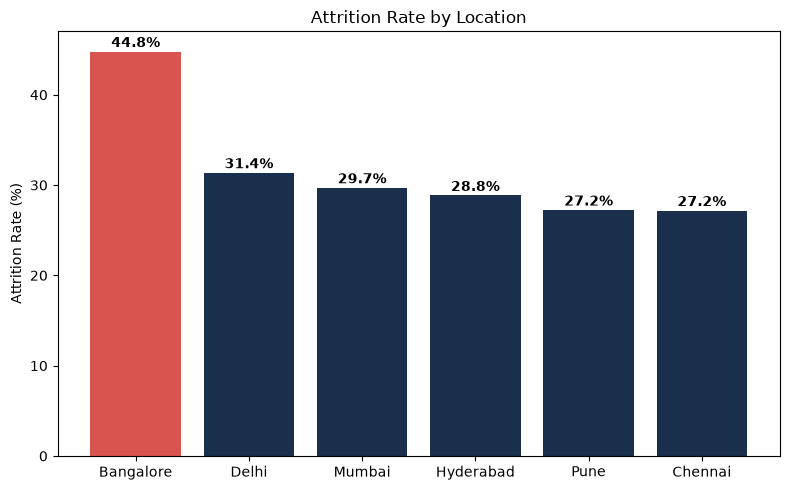

In [3]:
import matplotlib.pyplot as plt

location_attrition = hr.groupby('location')['attrited'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)

colors_list = ['#d9534f' if loc == 'Bangalore' else '#1a2f4b' for loc in location_attrition.index]

plt.figure(figsize=(8,5))
plt.bar(location_attrition.index, location_attrition.values, color=colors_list)
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Location')
for i, v in enumerate(location_attrition.values):
    plt.text(i, v+0.5, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('attrition_by_location.png', dpi=150)
plt.show()

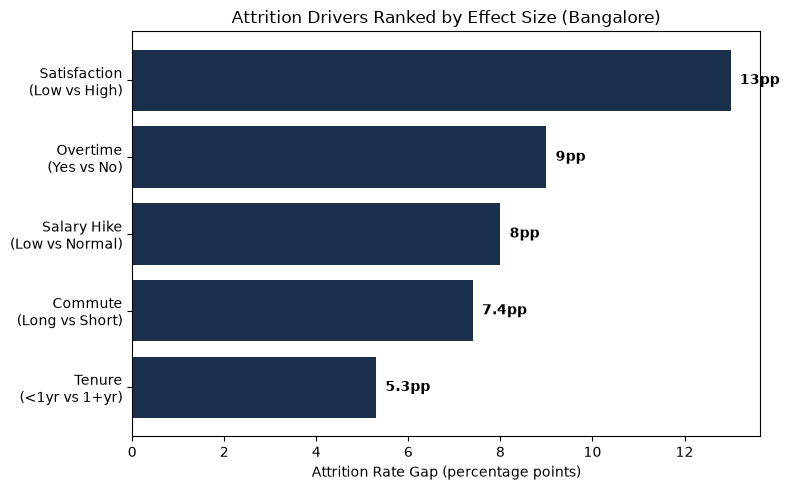

In [4]:
drivers = ['Satisfaction\n(Low vs High)', 'Overtime\n(Yes vs No)', 'Salary Hike\n(Low vs Normal)', 
           'Commute\n(Long vs Short)', 'Tenure\n(<1yr vs 1+yr)']
gap = [13, 9, 8, 7.4, 5.3]

plt.figure(figsize=(8,5))
plt.barh(drivers, gap, color='#1a2f4b')
plt.xlabel('Attrition Rate Gap (percentage points)')
plt.title('Attrition Drivers Ranked by Effect Size (Bangalore)')
plt.gca().invert_yaxis()
for i, v in enumerate(gap):
    plt.text(v+0.2, i, f"{v}pp", va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('drivers_ranked.png', dpi=150)
plt.show()

In [6]:
model_data = hr[['location', 'overtime', 'satisfaction_score', 'commute_km', 
                  'salary_hike_pct', 'attrited']].copy()
model_data = model_data.dropna()

model_data['attrited_flag'] = (model_data['attrited'] == 'Yes').astype(int)
model_data['overtime_flag'] = (model_data['overtime'] == 'Yes').astype(int)
model_data = pd.get_dummies(model_data, columns=['location'], drop_first=True)
model_data = model_data.drop(columns=['attrited', 'overtime'])

X = model_data.drop(columns=['attrited_flag'])
y = model_data['attrited_flag']

print(X.shape, y.shape)

(177788, 9) (177788,)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=8)
rf_model.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

              feature  importance
0  satisfaction_score    0.321220
3       overtime_flag    0.131996
2     salary_hike_pct    0.130531
1          commute_km    0.121175
8       location_Pune    0.077529
7     location_Mumbai    0.059966
6  location_Hyderabad    0.059457
4    location_Chennai    0.057853
5      location_Delhi    0.040274


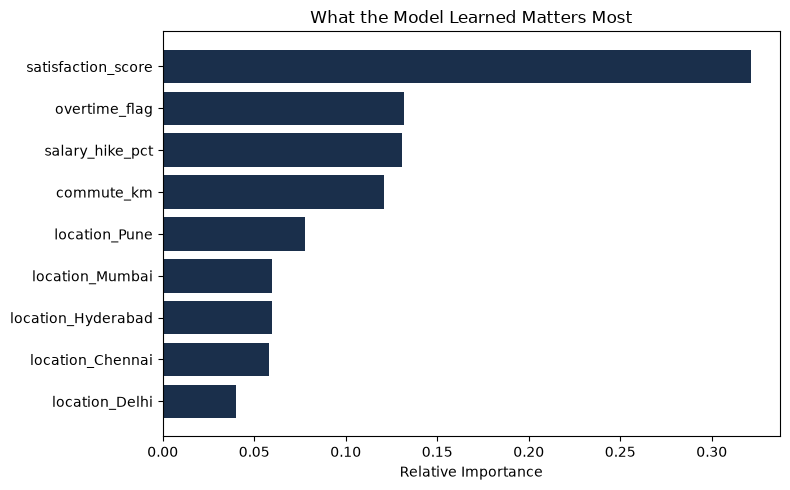

In [8]:
plt.figure(figsize=(8,5))
plt.barh(importances['feature'], importances['importance'], color='#1a2f4b')
plt.xlabel('Relative Importance')
plt.title('What the Model Learned Matters Most')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()